<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DES VENTES D'UNE LIBRAIRIE</h1>
</div>



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [ ]:
#Importation de la librairie Pandas
import pandas as pd

In [ ]:
#Importation de la librairie plotly express
import plotly.express as px
import seaborn as sns

In [ ]:
from google.colab import files

# Importation des tables
uploaded = files.upload()
#Imporation du fichier Customers
df_customers=pd.read_csv('customers.csv',delimiter=';')
#Importation du fichier Products
df_products=pd.read_csv('products.csv',delimiter=';')
#Importation du fichier Transactions
df_transactions=pd.read_csv('Transactions.csv',delimiter=';',dtype={'id_prod': object, 'date': object, 'session_id': object, 'client_id': object})

Saving customers.csv to customers.csv
Saving products.csv to products.csv
Saving Transactions.csv to Transactions.csv


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier customers.csv</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [ ]:
#Afficher des 5 premières lignes
df_customers.head(5)

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [ ]:
#Vérifier si il y a les lignes en doublons dans la colonne client_id
doublons_customers=df_customers[df_customers.duplicated(subset='client_id', keep=False)]
print (doublons_customers)

Empty DataFrame
Columns: [client_id, sex, birth]
Index: []


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier products.csv</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [ ]:
#Afficher des 5 premières lignes
df_products.head(5)

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [ ]:
#Vérifier si il y a les lignes en doublons dans la colonne client_id
doublons_products=df_products[df_products.duplicated(subset='id_prod', keep=False)]
print (doublons_products)

Empty DataFrame
Columns: [id_prod, price, categ]
Index: []


In [ ]:
#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?
prix_non_renseignes = df_products[df_products['price'].isna()]
prix_negatif = df_products[df_products['price'] < 0]
prix_nul = df_products[df_products['price'] == 0]
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'article avec un prix non renseignés: {}".format(len(prix_non_renseignes)))
#Afficher le prix minimum de la colonne "price"
prix_min= df_products['price'].min()
print("Le prix minimum est de : {}".format (prix_min))
#Afficher le prix maximum de la colonne "price"
prix_max= df_products['price'].max()
print("Le prix maximun est de : {}".format (prix_max))
#Affichier les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
print("\nProduits avec des prix negatif :")
print(prix_negatif)

Nombres d'article avec un prix non renseignés: 0
Le prix minimum est de : 0.62
Le prix maximun est de : 300.0

Produits avec des prix negatif :
Empty DataFrame
Columns: [id_prod, price, categ]
Index: []


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier transactions.csv</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB


In [ ]:
# Vérifier les valeurs manquantes par colonne
missing_values = df_transactions.isnull().sum()
# Filtrer uniquement les colonnes ayant des valeurs manquantes
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("✅ Aucune valeur manquante dans df_transactions.")
else:
    print("⚠️ Valeurs manquantes détectées :")
    print(missing_values)
#Suppression des NaN
df_transactions = df_transactions.dropna()
print(df_transactions.isnull().sum().sum())
df_transactions.info()

⚠️ Valeurs manquantes détectées :
id_prod       361041
date          361041
session_id    361041
client_id     361041
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 26.2+ MB


In [ ]:
# Expression régulière pour vérifier le format 'c_chiffres'
regex_pattern = r"^c_\d+$"
# Vérifier si chaque client_id respecte le format
df_transactions['client_id_valide'] = df_transactions['client_id'].astype(str).str.match(regex_pattern)
# Compter le nombre d'erreurs
erreurs = df_transactions[~df_transactions['client_id_valide']]
nombre_erreurs = erreurs.shape[0]
# Afficher les valeurs incorrectes si elles existent
if nombre_erreurs > 0:
    print(f"⚠️ {nombre_erreurs} erreurs détectées dans l'encodage de client_id :")
    print(erreurs[['client_id']].drop_duplicates())
else:
    print("✅ Tous les client_id respectent le format 'c_chiffres'.")

✅ Tous les client_id respectent le format 'c_chiffres'.


In [ ]:
code_client_unique = df_transactions['client_id'].nunique()
code_produit_unique = df_transactions['id_prod'].nunique()
print(f"Nombre de clients uniques : {code_client_unique}")
print(f"Nombre de produits uniques : {code_produit_unique}")

Nombre de clients uniques : 8600
Nombre de produits uniques : 3265


In [ ]:
#Afficher des 5 premières lignes
df_transactions.head(5)

,id_prod,date,session_id,client_id,client_id_valide
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,True
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,True
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,True
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,True
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,True


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jointure des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.1 - Joincture du fichier df_transactions et df_customers</h3>
</div>

In [ ]:
#Fusion des fichiers df_transactions et df_customers
df_fusion= df_transactions.merge(df_customers, on='client_id', how='left')

In [ ]:
#Y a t-il des lignes ne "matchant" entre les 2 fichiers?
df_fusion[df_fusion["client_id"].isnull()]

,id_prod,date,session_id,client_id,client_id_valide,sex,birth


In [ ]:
df_fusion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id_prod           687534 non-null  object
 1   date              687534 non-null  object
 2   session_id        687534 non-null  object
 3   client_id         687534 non-null  object
 4   client_id_valide  687534 non-null  bool  
 5   sex               687534 non-null  object
 6   birth             687534 non-null  int64 
dtypes: bool(1), int64(1), object(5)
memory usage: 32.1+ MB


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.2 - Joincture du fichier df_fusion et df_products</h3>
</div>

In [ ]:
#Fusion des fichiers df_fusion et df_products
df_merge= df_fusion.merge(df_products, on='id_prod', how='left')
#Y a t-il des lignes ne "matchant" entre les 2 fichiers?
df_merge[df_merge["id_prod"].isnull()]

,id_prod,date,session_id,client_id,client_id_valide,sex,birth,price,categ


In [ ]:
#Afficher les dimensions du dataset
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id_prod           687534 non-null  object 
 1   date              687534 non-null  object 
 2   session_id        687534 non-null  object 
 3   client_id         687534 non-null  object 
 4   client_id_valide  687534 non-null  bool   
 5   sex               687534 non-null  object 
 6   birth             687534 non-null  int64  
 7   price             687534 non-null  float64
 8   categ             687534 non-null  int64  
dtypes: bool(1), float64(1), int64(2), object(5)
memory usage: 42.6+ MB


In [ ]:
#Afficher les 5 premières lignes
df_merge.head(5)

,id_prod,date,session_id,client_id,client_id_valide,sex,birth,price,categ
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,True,f,1967,11.99,0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,True,m,1960,19.37,0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,True,m,1988,4.50,0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,True,f,1989,6.55,0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,True,f,1956,16.49,0


In [ ]:
# CALCUL DU CHIFFRE D'AFFAIRES TOTAL
print("CHIFFRES CLÉS GLOBAUX")
print("=" * 50)

# CA total
ca_total = df_merge['price'].sum()
print(f"💰 Chiffre d'affaires total : {ca_total:,.0f} €")

# Autres indicateurs clés
nb_clients = df_merge['client_id'].nunique()
nb_transactions = len(df_merge)
nb_produits = df_merge['id_prod'].nunique()
panier_moyen = df_merge['price'].mean()

print(f"👥 Nombre de clients uniques : {nb_clients:,}")
print(f"🛒 Nombre de transactions : {nb_transactions:,}")
print(f"📚 Nombre de produits vendus : {nb_produits}")
print(f"💳 Panier moyen : {panier_moyen:.2f} €")
print(f"📈 CA moyen par client : {ca_total/nb_clients:.2f} €")


CHIFFRES CLÉS GLOBAUX
💰 Chiffre d'affaires total : 12,027,663 €
👥 Nombre de clients uniques : 8,600
🛒 Nombre de transactions : 687,534
📚 Nombre de produits vendus : 3265
💳 Panier moyen : 17.49 €
📈 CA moyen par client : 1398.57 €


In [ ]:
#Convertir la colonne date au format date et ajout de la colonne mois
df_merge['date']= pd.to_datetime(df_merge['date'])
df_merge['mois']= df_merge['date'].dt.strftime('%B')
df_merge.head(5)

,id_prod,date,session_id,client_id,client_id_valide,sex,birth,price,categ,mois
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,True,f,1967,11.99,0,March
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,True,m,1960,19.37,0,March
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,True,m,1988,4.50,0,March
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,True,f,1989,6.55,0,March
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,True,f,1956,16.49,0,March


In [ ]:
#Calcul du chiffre d'affaires par produit et par mois
df_grouped= df_merge.groupby(['id_prod','mois']).agg(nbre_sessions=('id_prod','size'),prix_unitaire=('price','mean')).reset_index()
df_grouped['CA']=df_grouped['nbre_sessions']*df_grouped['prix_unitaire']
print(df_grouped)

      id_prod      mois  nbre_sessions  prix_unitaire      CA
0         0_0     April            118           3.75  442.50
1         0_0    August            105           3.75  393.75
2         0_0  December            117           3.75  438.75
3         0_0  February            102           3.75  382.50
4         0_0   January             81           3.75  303.75
...       ...       ...            ...            ...     ...
33539    2_99  December              1          84.99   84.99
33540    2_99   January              1          84.99   84.99
33541    2_99      July              2          84.99  169.98
33542    2_99       May              1          84.99   84.99
33543    2_99  November              2          84.99  169.98

[33544 rows x 5 columns]


In [ ]:
# Calcul de la moyenne mobile sur 3 mois
df_CA= df_grouped.groupby('mois')['CA'].sum().reset_index()
df_CA['moyenne_mobile_3mois']=df_CA['CA'].rolling(window=3, min_periods=1).mean()
df_CA['CA'] = df_CA['CA'].astype(int)
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_CA['mois'] = pd.Categorical(df_CA['mois'], categories=months_order, ordered=True)
df_CA = df_CA.sort_values(by='mois')
print(df_CA)

         mois       CA  moyenne_mobile_3mois
4     January  1042879          1.023756e+06
3    February   992251          1.005713e+06
7       March   997897          9.905401e+05
0       April   969108          9.691082e+05
8         May  1010076          9.960260e+05
6        June   980104          1.005534e+06
5        July   993618          1.009583e+06
1      August   988752          9.789301e+05
11  September  1001355          1.005613e+06
10    October  1002650          1.008520e+06
9    November  1012832          1.006935e+06
2    December  1036136          9.979990e+05


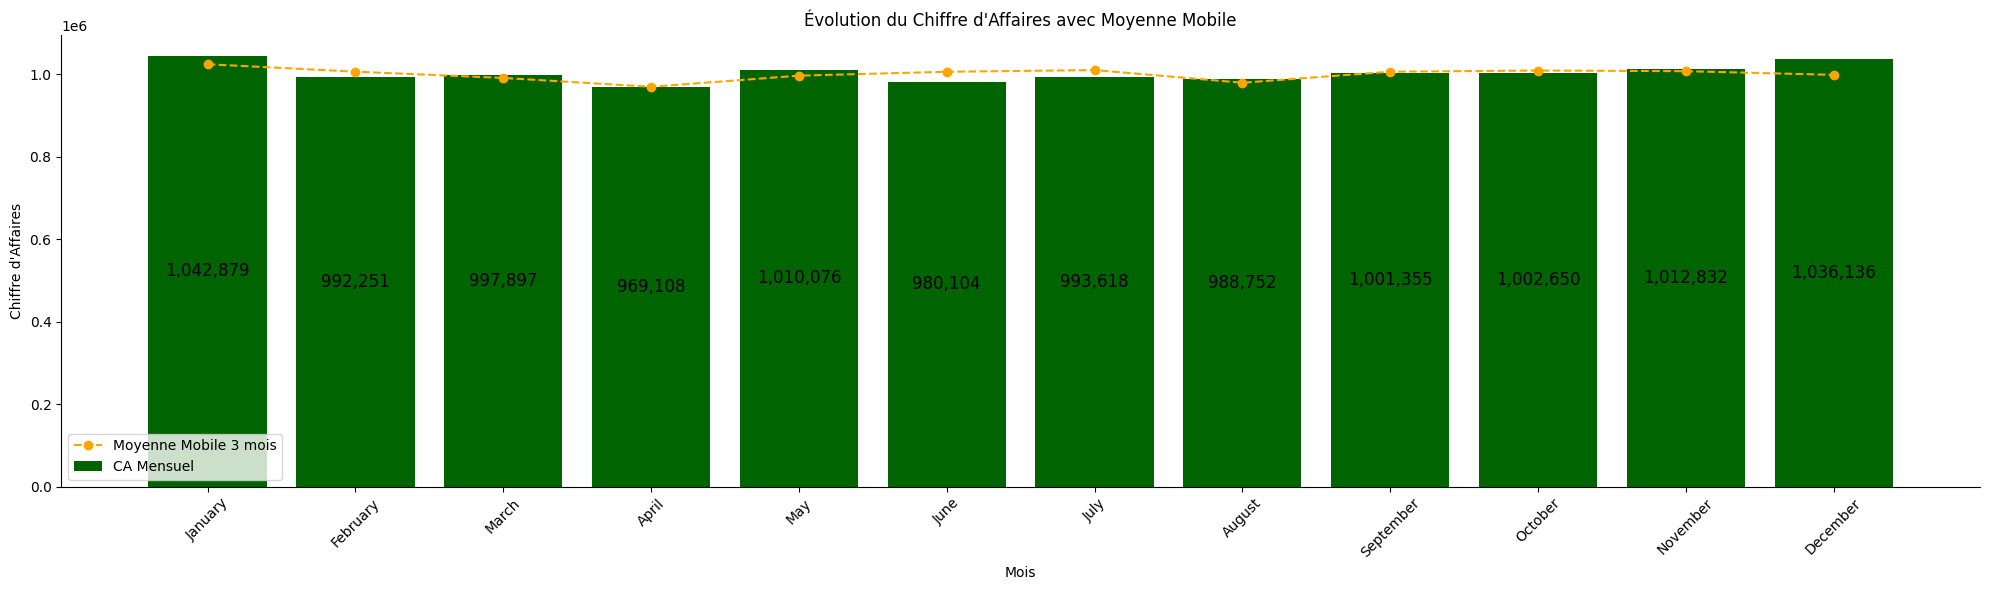

In [ ]:
# Evolution du chiffre d'affaire avec la moyenne mobile par mois
import matplotlib.pyplot as plt
# Créer la figure et les axes
plt.figure(figsize=(20, 6))
# Afficher le chiffre d'affaires en barres
bars= plt.bar(df_CA['mois'], df_CA['CA'], label="CA Mensuel", color='darkgreen')
# Ajouter des étiquettes de données sur les barres
for i in range(len(df_CA)):
    bar = bars[i]
    bar_width = bar.get_width()  # Récupérer la largeur de chaque barre
    bar_x = bar.get_x() + bar_width / 2  # Calculer la position horizontale centrée
    bar_height = bar.get_height()  # Récupérer la hauteur de chaque barre (valeur de CA)
   # Formater la valeur du CA avec des séparateurs de milliers
    formatted_value = f'{df_CA["CA"].iloc[i]:,}'  # Formatage du chiffre d'affaire avec séparateur de milliers
    # Placer l'étiquette au centre de la barre
    plt.text(bar_x, bar_height / 2,  # Placer l'étiquette au centre de la barre
             formatted_value, ha='center', va='center', fontsize=12, color='black')
ax = plt.gca()  # Récupérer les axes actuels
ax.spines['top'].set_visible(False)  # Enlever la bordure du haut
ax.spines['right'].set_visible(False)  # Enlever la bordure de droite
#Afficher la moyenne mobile en ligne
plt.plot(df_CA['mois'], df_CA['moyenne_mobile_3mois'], label="Moyenne Mobile 3 mois", linestyle='dashed', color='orange', marker='o')
# Ajouter des labels et un titre
plt.xlabel("Mois")
plt.ylabel("Chiffre d'Affaires")
plt.title("Évolution du Chiffre d'Affaires avec Moyenne Mobile")
# Ajouter la légende
plt.legend()
# Rotation des étiquettes de mois
plt.xticks(rotation=45)
# Afficher le graphique
plt.tight_layout()
plt.show()

In [ ]:
#Calcul du chiffre d'affaires par catégorie
df_aggr_categ= df_merge.groupby(['id_prod','categ','mois']).agg(nbre_sessions_categ=('id_prod','size'),prix_unitaire_categ=('price','mean')).reset_index()
df_aggr_categ['CA']=df_aggr_categ['nbre_sessions_categ']*df_aggr_categ['prix_unitaire_categ']
df_CA_categ= df_aggr_categ.groupby(['categ','mois'])['CA'].sum().reset_index()

months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_CA_categ['mois'] = pd.Categorical(df_CA_categ['mois'], categories=months_order, ordered=True)
df_CA_categ = df_CA_categ.sort_values(by='mois')
print(df_CA_categ)

    categ       mois         CA
4       0    January  345493.57
16      1    January  466372.33
28      2    January  231013.64
3       0   February  345654.33
15      1   February  393467.88
27      2   February  253129.05
31      2      March  219343.60
7       0      March  385094.11
19      1      March  393459.43
0       0      April  380219.72
12      1      April  351402.32
24      2      April  237486.20
32      2        May  247590.98
8       0        May  391059.06
20      1        May  371426.03
18      1       June  391074.10
30      2       June  237152.57
6       0       June  351878.01
29      2       July  279277.74
17      1       July  382492.99
5       0       July  331847.79
13      1     August  374351.47
25      2     August  269290.21
1       0     August  345110.38
23      1  September  385993.32
11      0  September  429683.15
35      2  September  185678.74
22      1    October  407306.40
10      0    October  386680.00
34      2    October  208664.53
21      

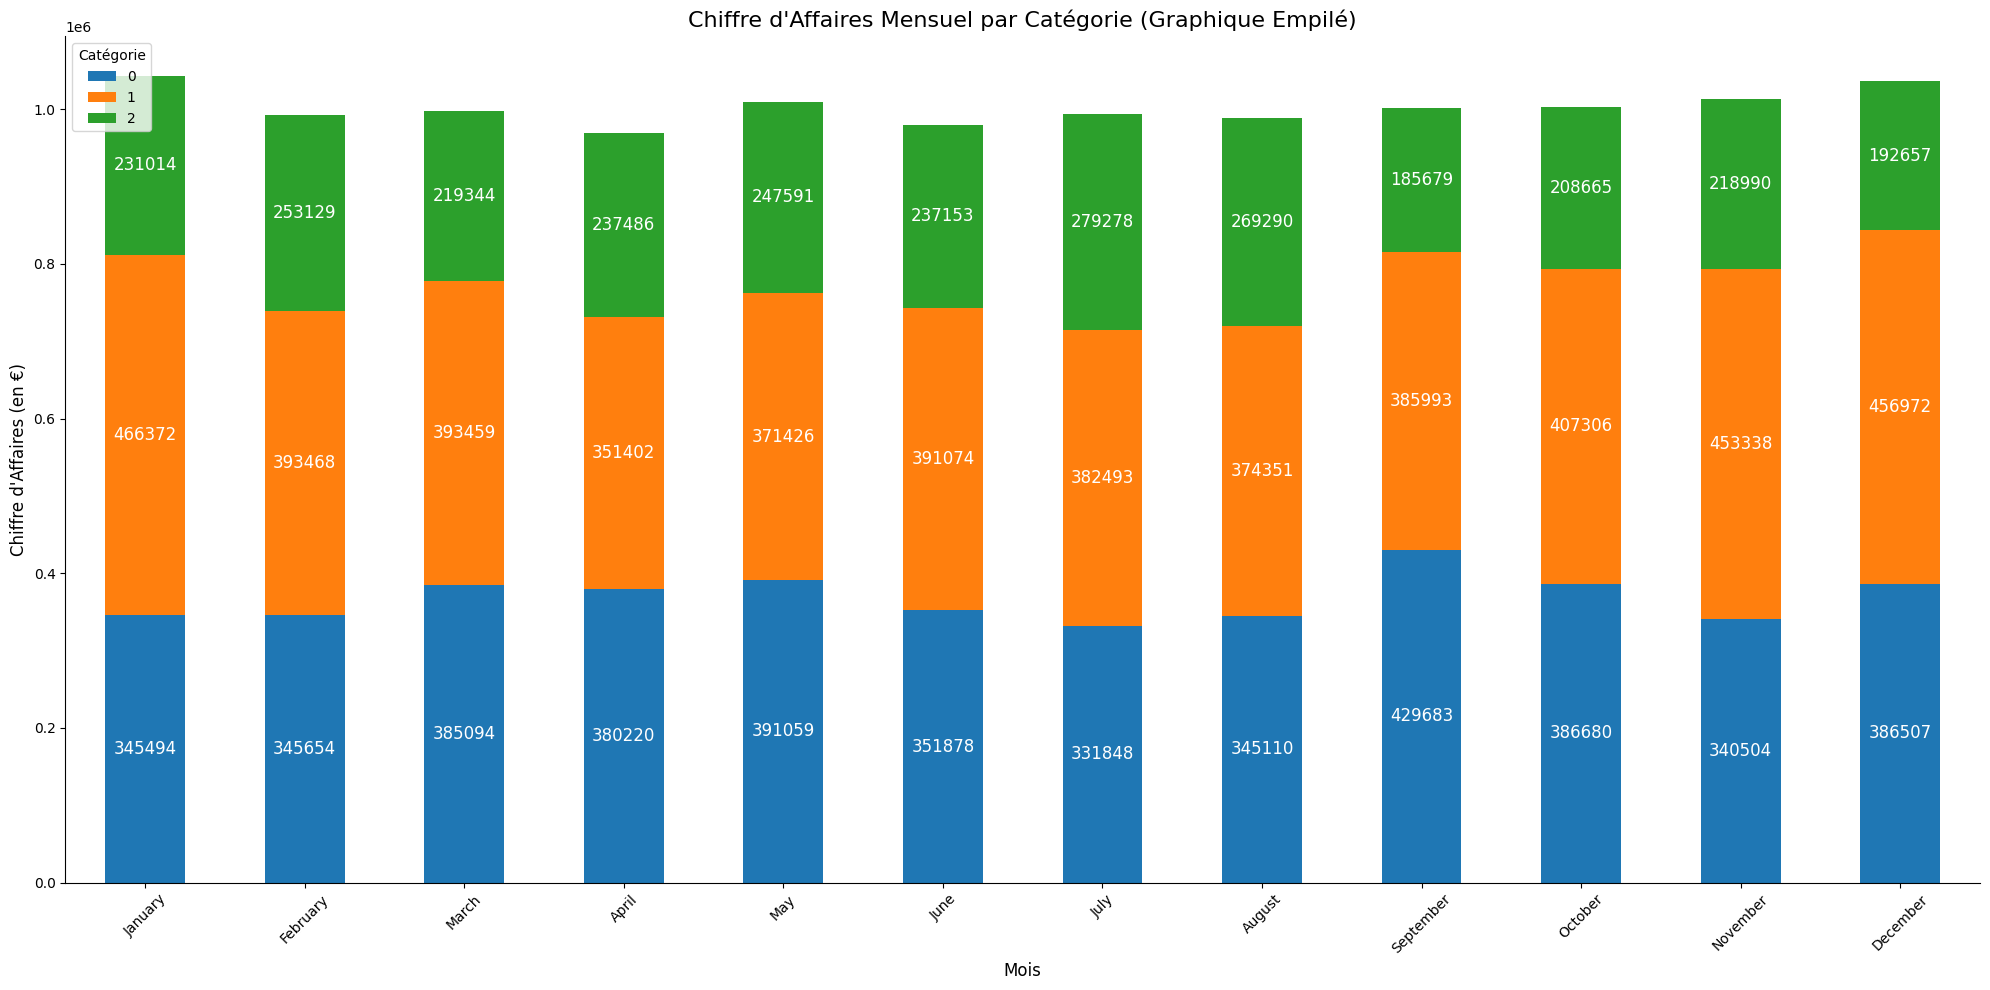

In [ ]:
df_pivot = df_CA_categ.pivot(index='mois', columns='categ', values='CA').fillna(0)

# Création du graphique empilé
ax = df_pivot.plot(kind='bar', stacked=True, figsize=(20, 10))
# Ajouter des étiquettes de données sur chaque barre
for p in ax.patches:
    # Calculer la position de l'étiquette
    height = p.get_height()
    width = p.get_width()
    x = p.get_x() + width / 2
    y = p.get_y() + height / 2

    # Ajouter l'étiquette avec un léger décalage
    ax.text(x, y, f'{height:.0f}', ha='center', va='center', fontsize=12, color='white')
ax = plt.gca()  # Récupérer les axes actuels
ax.spines['top'].set_visible(False)  # Enlever la bordure du haut
ax.spines['right'].set_visible(False)  # Enlever la bordure de droite
# Ajouter un titre et des labels
plt.title("Chiffre d'Affaires Mensuel par Catégorie (Graphique Empilé)", fontsize=16)
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Chiffre d\'Affaires (en €)', fontsize=12)

# Faire pivoter les étiquettes des mois
plt.xticks(rotation=45)

# Ajouter une légende
plt.legend(title="Catégorie", loc='upper left')

# Ajuster l'affichage
plt.tight_layout()

# Afficher le graphique
plt.show()

In [ ]:
#Calcul du nombre de client par mois
df_nbr_clts = df_merge.groupby('mois')['client_id'].nunique().reset_index()
df_nbr_clts.rename(columns={'client_id': 'nbr_clients'}, inplace=True)
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_nbr_clts['mois'] = pd.Categorical(df_nbr_clts['mois'], categories=months_order, ordered=True)
df_nbr_clts = df_nbr_clts.sort_values(by='mois')
print(df_nbr_clts)

         mois  nbr_clients
4     January         7132
3    February         7076
7       March         7160
0       April         7102
8         May         7098
6        June         6963
5        July         7107
1      August         7147
11  September         7126
10    October         7500
9    November         7259
2    December         7206


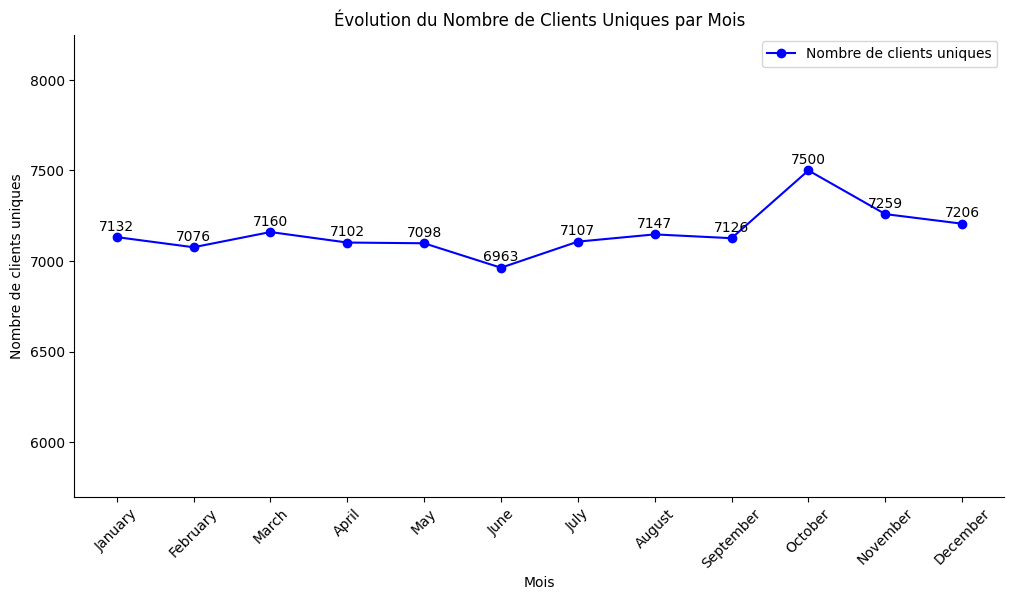

In [ ]:
# Evolution du nombre de clients par mois
# Trier les mois dans l'ordre chronologique
df_nbr_clts = df_nbr_clts.sort_values(by='mois')
# Créer la figure
plt.figure(figsize=(12, 6))
# Tracer la ligne
plt.plot(df_nbr_clts['mois'], df_nbr_clts['nbr_clients'], marker='o', linestyle='-', color='b', label="Nombre de clients uniques")
# Ajouter les étiquettes de données centrées sur les points
for i in range(len(df_nbr_clts)):
    plt.text(df_nbr_clts['mois'].iloc[i], df_nbr_clts['nbr_clients'].iloc[i]+20,
             f"{df_nbr_clts['nbr_clients'].iloc[i]}", ha='center', va='bottom', fontsize=10, color='black')
# Augmenter la limite supérieure de l'axe Y
plt.ylim(5700, df_nbr_clts['nbr_clients'].max() * 1.1)  # 20% de marge au-dessus du max
ax = plt.gca()  # Récupérer les axes actuels
ax.spines['top'].set_visible(False)  # Enlever la bordure du haut
ax.spines['right'].set_visible(False)  # Enlever la bordure de droite
# Ajouter les titres et labels
plt.xlabel("Mois")
plt.ylabel("Nombre de clients uniques")
plt.title("Évolution du Nombre de Clients Uniques par Mois")
# Rotation des labels sur l'axe des X pour une meilleure lisibilité
plt.xticks(rotation=45)
# Ajouter la légende
plt.legend()
# Afficher le graphique
plt.show()

In [ ]:
#Calcul du nombre de transactions par mois
df_nbr_trans = df_merge.groupby('mois')['session_id'].count().reset_index()
df_nbr_trans.rename(columns={'session_id': 'nbr_trans'}, inplace=True)
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_nbr_trans['mois'] = pd.Categorical(df_nbr_trans['mois'], categories=months_order, ordered=True)
df_nbr_trans = df_nbr_trans.sort_values(by='mois')
print(df_nbr_trans)

         mois  nbr_trans
4     January      58281
3    February      55139
7       March      58297
0       April      56045
8         May      58260
6        June      55354
5        July      53408
1      August      54194
11  September      61620
10    October      58986
9    November      56874
2    December      61076


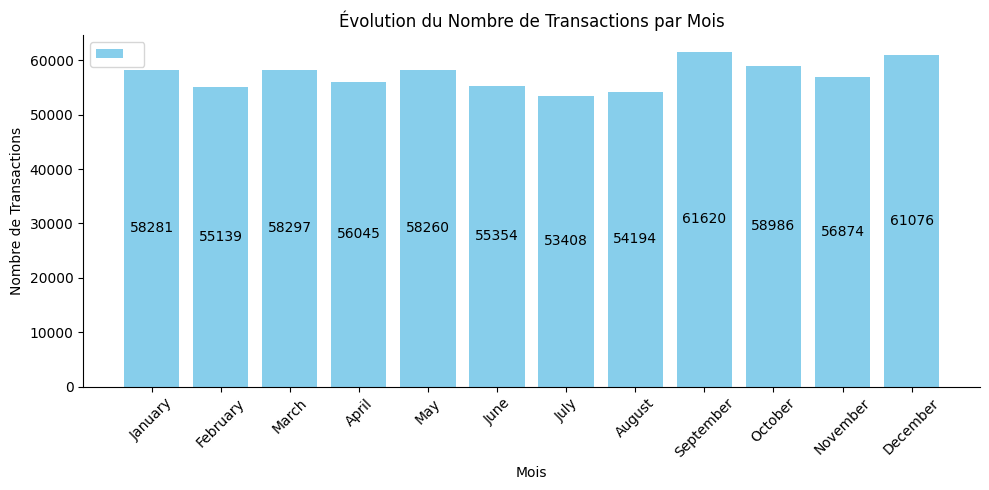

In [ ]:
#Evolution du nombre de transactions par mois
plt.figure(figsize=(10, 5))
bars = plt.bar(df_nbr_trans['mois'], df_nbr_trans['nbr_trans'], color='skyblue',label= ' ')
# Ajouter des étiquettes de données centrées sur les barres
for bar, valeur in zip(bars, df_nbr_trans['nbr_trans']):
    bar_width = bar.get_width()  # Récupérer la largeur de la barre
    bar_x = bar.get_x() + bar_width / 2  # Centrer l'étiquette
    bar_height = bar.get_height()  # Récupérer la hauteur (valeur)
    # Afficher l'étiquette centrée
    plt.text(bar_x, bar_height / 2,  # Centrage vertical
             f"{valeur:.0f}", ha='center', va='center', fontsize=10, color='black')
ax = plt.gca()  # Récupérer les axes actuels
ax.spines['top'].set_visible(False)  # Enlever la bordure du haut
ax.spines['right'].set_visible(False)  # Enlever la bordure de droite
# Ajouter des titres et labels
plt.xlabel("Mois")
plt.ylabel("Nombre de Transactions")
plt.title("Évolution du Nombre de Transactions par Mois")
plt.xticks(rotation=45)
plt.legend()
# Afficher le graphique
plt.tight_layout()
plt.show()


ANALYSE DE TENDANCE DES TRANSACTIONS :
📊 RÉSULTATS DE L'ANALYSE DE TENDANCE :
   - Tendance mensuelle : 227 transactions/mois
   - Coefficient de corrélation : 0.316
   - P-value : 0.317
📊 CONCLUSION : Pas de tendance significative détectée
   → Les variations mensuelles sont principalement dues au hasard

📈 ANALYSE DE LA CROISSANCE MENSUELLE :
   - Croissance moyenne : 0.6%
   - Croissance médiane : -3.5%
   - Écart-type : 6.3%

🔝 MOIS AVEC LES PLUS FORTES VARIATIONS :
   - Plus forte hausse : September (+13.7%)
   - Plus forte baisse : February (-5.4%)


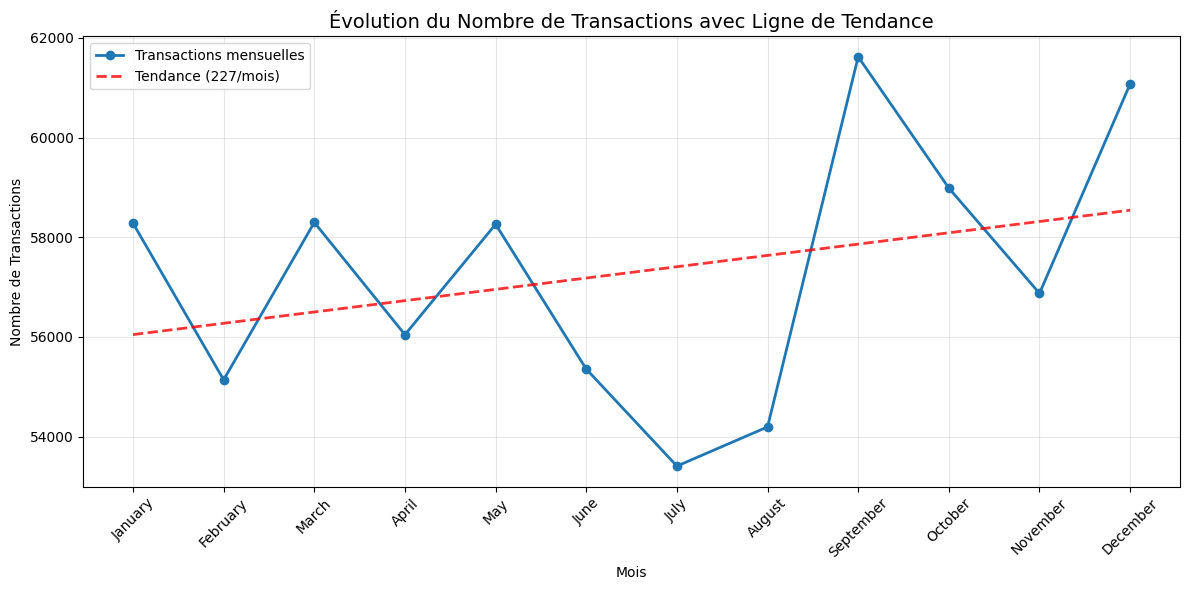


💡 IMPLICATIONS BUSINESS :
   📊 Activité transactionnelle stable
   ➡️ Recommandation : Maintenir le niveau actuel
   🎯 Action : Surveiller les variations saisonnières


In [ ]:
# ANALYSE DE TENDANCE DES TRANSACTIONS
import numpy as np
from scipy import stats

print("\nANALYSE DE TENDANCE DES TRANSACTIONS :")
print("=" * 60)

# Calcul de la tendance linéaire
x = np.arange(len(df_nbr_trans))
slope, intercept, r_value, p_value, std_err = stats.linregress(x, df_nbr_trans['nbr_trans'])

print(f"📊 RÉSULTATS DE L'ANALYSE DE TENDANCE :")
print(f"   - Tendance mensuelle : {slope:.0f} transactions/mois")
print(f"   - Coefficient de corrélation : {r_value:.3f}")
print(f"   - P-value : {p_value:.3f}")

# Interprétation de la tendance
if p_value < 0.05:
    if slope > 0:
        print("📈 CONCLUSION : Tendance significative à la HAUSSE")
        print(f"   → Les transactions augmentent de {slope:.0f} par mois en moyenne")
    elif slope < 0:
        print("📉 CONCLUSION : Tendance significative à la BAISSE")
        print(f"   → Les transactions diminuent de {abs(slope):.0f} par mois en moyenne")
    else:
        print("➡️ CONCLUSION : Tendance stable")
else:
    print("📊 CONCLUSION : Pas de tendance significative détectée")
    print("   → Les variations mensuelles sont principalement dues au hasard")

# Calcul de la croissance mensuelle
df_nbr_trans['croissance'] = df_nbr_trans['nbr_trans'].pct_change() * 100

print(f"\n📈 ANALYSE DE LA CROISSANCE MENSUELLE :")
print(f"   - Croissance moyenne : {df_nbr_trans['croissance'].mean():.1f}%")
print(f"   - Croissance médiane : {df_nbr_trans['croissance'].median():.1f}%")
print(f"   - Écart-type : {df_nbr_trans['croissance'].std():.1f}%")

# Identifier les mois avec les plus fortes variations
mois_max = df_nbr_trans.loc[df_nbr_trans['croissance'].idxmax(), 'mois']
croissance_max = df_nbr_trans['croissance'].max()
mois_min = df_nbr_trans.loc[df_nbr_trans['croissance'].idxmin(), 'mois']
croissance_min = df_nbr_trans['croissance'].min()

print(f"\n🔝 MOIS AVEC LES PLUS FORTES VARIATIONS :")
print(f"   - Plus forte hausse : {mois_max} (+{croissance_max:.1f}%)")
print(f"   - Plus forte baisse : {mois_min} ({croissance_min:.1f}%)")

# Graphique avec ligne de tendance
plt.figure(figsize=(12, 6))
plt.plot(df_nbr_trans['mois'], df_nbr_trans['nbr_trans'], marker='o', linewidth=2, label='Transactions mensuelles')

# Ajouter la ligne de tendance
trend_line = slope * x + intercept
plt.plot(df_nbr_trans['mois'], trend_line, "--", alpha=0.8, color='red', linewidth=2, label=f'Tendance ({slope:.0f}/mois)')

# Mise en forme
plt.title("Évolution du Nombre de Transactions avec Ligne de Tendance", fontsize=14)
plt.xlabel("Mois")
plt.ylabel("Nombre de Transactions")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n💡 IMPLICATIONS BUSINESS :")
if slope > 0 and p_value < 0.05:
    print("   ✅ Croissance soutenue de l'activité transactionnelle")
    print("   📈 Recommandation : Anticiper l'augmentation de la charge")
    print("   🎯 Action : Renforcer les capacités de traitement")
elif slope < 0 and p_value < 0.05:
    print("   ⚠️ Déclin de l'activité transactionnelle")
    print("   📉 Recommandation : Investiguer les causes de la baisse")
    print("   🎯 Action : Mettre en place des actions correctives")
else:
    print("   📊 Activité transactionnelle stable")
    print("   ➡️ Recommandation : Maintenir le niveau actuel")
    print("   🎯 Action : Surveiller les variations saisonnières")


In [ ]:
#Calcul du nombre de produit vendus par mois
df_nbr_pdts = df_merge.groupby('mois')['id_prod'].nunique().reset_index()
df_nbr_pdts.rename(columns={'id_prod': 'nbr_produit_vendus'}, inplace=True)
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_nbr_pdts['mois'] = pd.Categorical(df_nbr_pdts['mois'], categories=months_order, ordered=True)
df_nbr_pdts = df_nbr_pdts.sort_values(by='mois')
print(df_nbr_pdts)

         mois  nbr_produit_vendus
4     January                2796
3    February                2775
7       March                2811
0       April                2799
8         May                2798
6        June                2749
5        July                2756
1      August                2774
11  September                2846
10    October                2854
9    November                2776
2    December                2810


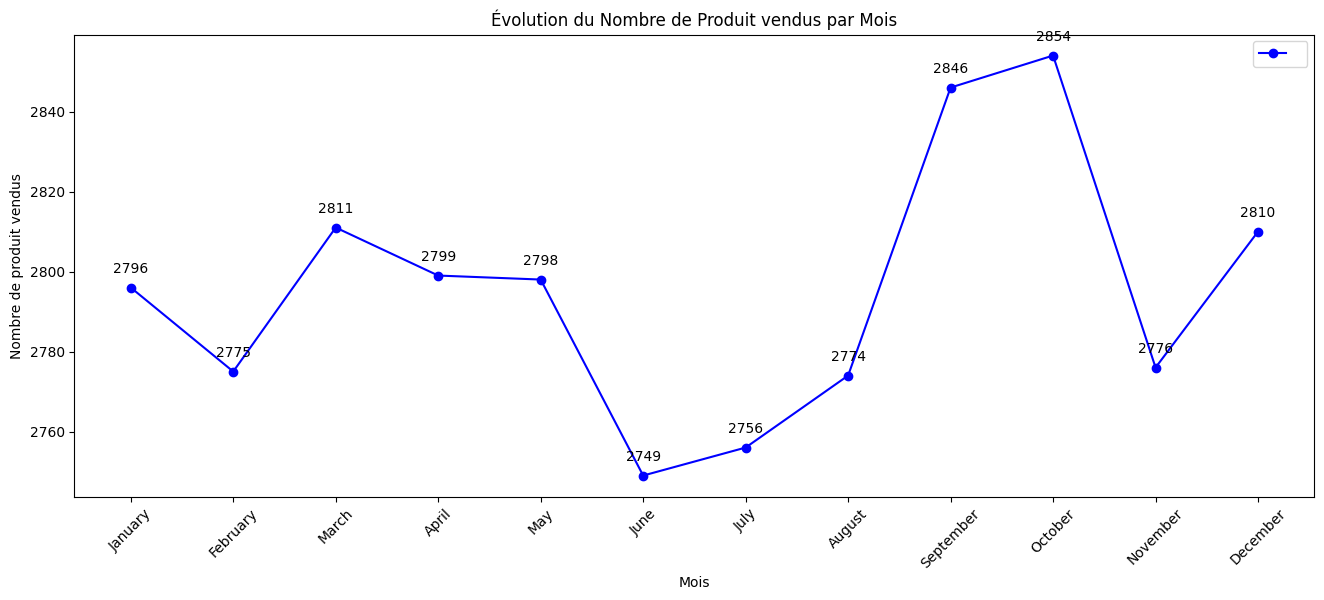

In [ ]:
# Evolution du nombre de produit vendus par mois
# Créer la figure
plt.figure(figsize=(16, 6))
# Tracer la ligne
plt.plot(df_nbr_pdts['mois'], df_nbr_pdts['nbr_produit_vendus'], marker='o', linestyle='-', color='b', label=" ")
# Ajouter les étiquettes de données centrées sur les points
for i in range(len(df_nbr_pdts)):
    plt.text(df_nbr_pdts['mois'].iloc[i], df_nbr_pdts['nbr_produit_vendus'].iloc[i]+3,
             f"{df_nbr_pdts['nbr_produit_vendus'].iloc[i]}", ha='center', va='bottom', fontsize=10, color='black')

# Ajouter les titres et labels
plt.xlabel("Mois")
plt.ylabel("Nombre de produit vendus")
plt.title("Évolution du Nombre de Produit vendus par Mois")
# Rotation des labels sur l'axe des X pour une meilleure lisibilité
plt.xticks(rotation=45)
# Ajouter la légende
plt.legend()
# Afficher le graphique
plt.show()

In [ ]:
#Calcul du CA par clients
df_aggr_clts= df_merge.groupby('client_id')['price'].sum().reset_index()
#Effectuer le tri dans l'ordre décroissant du CA
df_aggr_clts_desc = df_aggr_clts.sort_values(by="price", ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_aggr_clts_desc = df_aggr_clts_desc.reset_index(drop=True)
#Afficher les 10 premier clients en CA
top_10_clts= round(df_aggr_clts_desc.head(10),0)
#Graphique en barre des 10 premiers clients avec plotly express
import plotly.express as px
fig = px.bar(top_10_clts[::-1], y='client_id',x='price',orientation="h",title='Top 10 des clients par CA',
             labels={'post_title':'client_id', 'price':'Chiffre d affaires'},
             text='price',width=1080, height=1080)
fig.show()

In [ ]:
#Calcul du CA par produits
df_aggr_prdts= df_merge.groupby('id_prod')['price'].sum().reset_index()
#Effectuer le tri dans l'ordre décroissant du CA
df_aggr_prdts_desc = df_aggr_prdts.sort_values(by="price", ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_aggr_prdts_desc = df_aggr_prdts_desc.reset_index(drop=True)
#Afficher les 10 premier produits en CA
top_10_prdts= round(df_aggr_prdts_desc.head(10),0)
#Graphique en barre des 10 premiers clients avec plotly express
import plotly.express as px
fig = px.bar(top_10_prdts[::-1], y='id_prod',x='price',orientation="h",title='Top 10 des produits par CA',
             labels={'post_title':'id_prod', 'price':'Chiffre d affaires'},
             text='price',width=1080, height=1080)
fig.show()

In [ ]:
#Topflop des produits

#Effectuer le tri dans l'ordre croissant du CA
df_aggr_prts_flop = df_aggr_prdts.sort_values(by="price", ascending=True)
#Réinitialiser l'index du dataset par un reset_index
df_aggr_prts_flop = df_aggr_prts_flop.reset_index(drop=True)
#Afficher les 10 flop produits en CA
topflop_10_prdts= round(df_aggr_prts_flop.head(10),0)
#Graphique en barre des 10 premiers clients avec plotly express
fig = px.bar(topflop_10_prdts[::-1], y='id_prod',x='price',orientation="h",title='Flop 10 des produits par CA',
             labels={'post_title':'id_prod', 'price':'Chiffre d affaires'},
             text='price',width=1080, height=1080)
fig.show()


In [ ]:
#Calcul du CA par catégories
df_aggr_cat= df_merge.groupby(['id_prod','categ']).agg(nbre_sessions_cat=('id_prod','size'),prix_unitaire_cat=('price','mean')).reset_index()
df_aggr_cat['CA']=df_aggr_cat['nbre_sessions_cat']*df_aggr_cat['prix_unitaire_cat']
df_CA_cat= df_aggr_cat.groupby('categ')['CA'].sum().astype(int).reset_index()
#Répartition du CA par catégories
fig = px.pie(df_CA_cat, values='CA', names='categ', hole=0.1,
             title="Répartition du Chiffre d'Affaires par Catégorie",
             labels={'categ': 'Catégorie', 'CA': 'Chiffre d\'Affaires (€)'},
             color_discrete_sequence=px.colors.qualitative.Pastel)
# Mise à jour des étiquettes de texte pour afficher le pourcentage et le montant
fig.update_traces(
    textinfo='percent+value',  # Afficher le pourcentage + valeur (€)
    hovertemplate='<b>%{label}</b><br>CA: %{value:.0f} €<br>(%{percent:.2%})',  # Info au survol
    textposition='inside',  # Centrer les labels dans les tranches
    insidetextorientation='radial'  # Orientation du texte
)
# Afficher le graphique
fig.show()

In [ ]:
#Calcul de l'age des clients
année_actuelle= pd.Timestamp.now().year
df_merge['Age']= année_actuelle-df_merge['birth']
# Définition des nouvelles tranches d'âge
bins = [21, 29, 39, 49, 59, 69, 79, 100]  # Intervalle des âges
labels = ["21-29 ans", "30-39 ans", "40-49 ans", "50-59 ans", "60-69 ans", "70-79 ans", "80-100 ans"]   # Noms des tranches
# Ajouter la colonne 'Tranche_Age'
df_merge['Tranche_Age'] = pd.cut(df_merge['Age'], bins=bins, labels=labels, right=True)
# Afficher un aperçu
df_merge[['birth', 'Age', 'Tranche_Age']].head()

,birth,Age,Tranche_Age
0,1967,58,50-59 ans
1,1960,65,60-69 ans
2,1988,37,30-39 ans
3,1989,36,30-39 ans
4,1956,69,60-69 ans


In [ ]:
#Répartition du chiffre d'affaires par tranche d'age
df_aggr_age= df_merge.groupby(['id_prod','Tranche_Age'],observed=False).agg(nbre_sessions_age=('id_prod','size'),prix_unitaire_age=('price','mean')).reset_index()
df_aggr_age['CA']=df_aggr_age['nbre_sessions_age']*df_aggr_age['prix_unitaire_age']
df_CA_age= df_aggr_age.groupby('Tranche_Age',observed=False)['CA'].sum().astype(int).reset_index()
#Trie du chiffre par odre décroissant
df_aggr_age_desc = df_CA_age.sort_values(by="CA", ascending=True)
#Réinitialiser l'index du dataset par un reset_index
df_aggr_age_desc = df_aggr_age_desc.reset_index(drop=True)
# Création du graphique en anneau (donut chart)
fig = px.pie(df_aggr_age_desc, values='CA', names='Tranche_Age',
             title="Répartition du Chiffre d'Affaires par Tranche d'Âge",
             hole=0.4,  # Crée l'effet d'anneau
             color_discrete_sequence=px.colors.qualitative.Set2)  # Palette de couleurs
# Ajout des étiquettes (montant + pourcentage)
fig.update_traces(textinfo='percent+value',
                  texttemplate=' %{value}€ (%{percent})')
# Déplacer la légende vers la droite
fig.update_layout(legend=dict(x=1.2, y=0.5))  # x > 1 déplace la légende à droite
# Affichage du graphique
fig.show()

In [ ]:
#Répartition du chiffre d'affaires selon le sexe et la tranche d'age
df_aggr_sex_age= df_merge.groupby(['id_prod','sex','Tranche_Age'],observed=False).agg(nbre_sessions_sex_age=('id_prod','size'),prix_unitaire_sex_age=('price','mean')).reset_index()
df_aggr_sex_age['CA']=df_aggr_sex_age['nbre_sessions_sex_age']*df_aggr_sex_age['prix_unitaire_sex_age']
df_CA_sex_age= df_aggr_sex_age.groupby(['sex','Tranche_Age'],observed=False)['CA'].sum().astype(int).reset_index()
#Trie du chiffre par odre décroissant
df_aggr_age_sex_desc = df_CA_sex_age.sort_values(by="CA", ascending=True)
#Réinitialiser l'index du dataset par un reset_index
df_aggr_age_sex_desc = df_aggr_age_sex_desc.reset_index(drop=True)
print(df_aggr_age_sex_desc)

   sex Tranche_Age       CA
0    m  80-100 ans   120207
1    f  80-100 ans   150760
2    m   70-79 ans   248401
3    f   70-79 ans   309530
4    m   60-69 ans   547693
5    f   60-69 ans   561631
6    f   21-29 ans   797524
7    m   50-59 ans   952958
8    m   21-29 ans  1065395
9    f   50-59 ans  1133719
10   m   30-39 ans  1187470
11   f   30-39 ans  1267531
12   f   40-49 ans  1413307
13   m   40-49 ans  1655112


In [ ]:
import plotly.graph_objects as go
# Transformation des données en table pivotée
df_heatmap = df_aggr_age_sex_desc.pivot(index='Tranche_Age', columns='sex', values='CA')
# Formater les valeurs du CA avec un séparateur d'espace pour les milliers
df_heatmap_formatted = df_heatmap.apply(lambda col: col.apply(lambda x: f'{x:,.0f}'.replace(',', ' ')))
# Création de la heatmap
fig = go.Figure(data=go.Heatmap(
    z=df_heatmap.values,
    x=df_heatmap.columns,
    y=df_heatmap.index,
    colorscale='Blues',
    text=df_heatmap_formatted.values,  # Valeurs formatées pour l'affichage
    texttemplate="%{text}",
    showscale=True))
fig.update_layout(title="Carte de Chaleur du Chiffre d'Affaires par Sexe et Tranche d'Âge",
                  xaxis_title="Sexe",
                  yaxis_title="Tranche d'Âge")
fig.show()

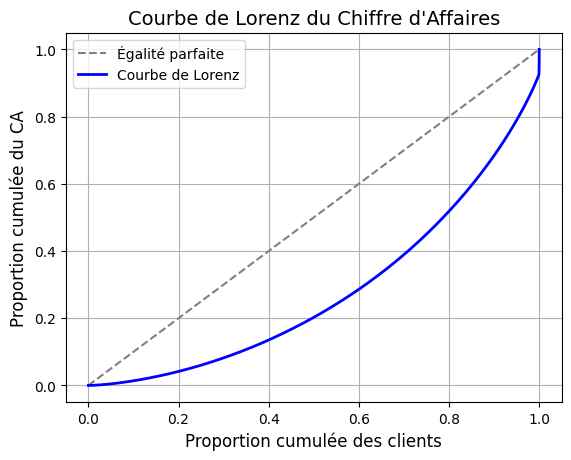

In [ ]:
import numpy as np
#Calcul du CA par client
df_ca_clts= df_merge.groupby('client_id')['price'].sum().reset_index()['price'].sort_values()
# Calculer la proportion cumulée du CA
cumulative_ca = df_ca_clts.cumsum()  # Cumul des CA
total_ca = df_ca_clts.sum()  # Total du CA
cumulative_proportion = cumulative_ca / total_ca  # Proportion cumulée du CA
# Calculer la proportion cumulée des clients
cumulative_clients = np.arange(1, len(df_ca_clts) + 1) / len(df_ca_clts)  # Proportion cumulée des clients
# Ajouter la ligne d'égalité (diagonale)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Égalité parfaite")
# Tracer la courbe de Lorenz
plt.plot(cumulative_clients, cumulative_proportion, label="Courbe de Lorenz", color='blue', linewidth=2)
# Ajouter les labels et le titre
plt.title("Courbe de Lorenz du Chiffre d'Affaires", fontsize=14)
plt.xlabel("Proportion cumulée des clients", fontsize=12)
plt.ylabel("Proportion cumulée du CA", fontsize=12)
# Ajouter une légende
plt.legend()
# Afficher le graphique
plt.grid(True)
plt.show()

In [ ]:
# Identification des clients BtoB par méthode statistique (Z-score)
from scipy.stats import zscore

print("IDENTIFICATION ET ANALYSE DES CLIENTS BtoB")
print("=" * 80)

# 1. Calcul du CA par client
print("1. Analyse de la distribution du CA par client :")
print("-" * 50)

df_ca_clients = df_merge.groupby('client_id')['price'].sum().reset_index()
df_ca_clients.columns = ['client_id', 'ca_total']

print(f"Nombre total de clients : {len(df_ca_clients)}")
print(f"CA moyen par client : {df_ca_clients['ca_total'].mean():.2f} €")
print(f"CA médian par client : {df_ca_clients['ca_total'].median():.2f} €")

# 2. Identification des outliers (clients BtoB) par Z-score
print("\n2. Identification des clients BtoB (méthode Z-score) :")
print("-" * 60)

df_ca_clients['zscore'] = zscore(df_ca_clients['ca_total'])

# Clients avec Z-score > 3 sont considérés comme des outliers (BtoB)
seuil_zscore = 3
clients_btob = df_ca_clients[df_ca_clients['zscore'] > seuil_zscore]

print(f"Seuil Z-score utilisé : {seuil_zscore}")
print(f"Nombre de clients BtoB identifiés : {len(clients_btob)}")

if len(clients_btob) > 0:
    print("\nClients BtoB identifiés :")
    for idx, row in clients_btob.iterrows():
        print(f"  - {row['client_id']} : {row['ca_total']:,.0f} € (Z-score: {row['zscore']:.2f})")

# 3. Classification des clients
print("\n3. Classification de la clientèle :")
print("-" * 50)

df_merge['type_client'] = df_merge['client_id'].apply(
    lambda x: 'BtoB' if x in clients_btob['client_id'].values else 'Particulier'
)

# Répartition du CA par type de client
ca_par_type = df_merge.groupby('type_client')['price'].agg(['sum', 'count']).round(2)
ca_par_type.columns = ['CA_total', 'Nb_transactions']
ca_par_type['Pourcentage_CA'] = (ca_par_type['CA_total'] / ca_par_type['CA_total'].sum() * 100).round(2)

print("Répartition du chiffre d'affaires :")
print(ca_par_type)

# 4. Visualisation de la répartition BtoB vs Particuliers
print("\n4. Visualisation :")
print("-" * 50)

# Graphique en camembert
fig = px.pie(
    values=ca_par_type['CA_total'],
    names=ca_par_type.index,
    title="Répartition du Chiffre d'Affaires : BtoB vs Particuliers",
    color_discrete_sequence=['#FF6B6B', '#4ECDC4']
)

fig.update_traces(
    textinfo='percent+value',
    hovertemplate='<b>%{label}</b><br>CA: %{value:,.0f} €<br>(%{percent})',
)

fig.show()

# 5. Analyse comportementale des clients BtoB
if len(clients_btob) > 0:
    print("\n5. Analyse comportementale des clients BtoB :")
    print("-" * 60)

    # Données des clients BtoB
    df_btob = df_merge[df_merge['type_client'] == 'BtoB']
    df_particuliers = df_merge[df_merge['type_client'] == 'Particulier']

    # Statistiques comparatives
    stats_btob = df_btob.groupby('client_id').agg({
        'price': ['sum', 'count', 'mean'],
        'categ': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0]
    }).round(2)

    stats_btob.columns = ['CA_total', 'Nb_transactions', 'Panier_moyen', 'Categ_preferee']

    print("Profil des clients BtoB :")
    print(stats_btob)

    # CORRECTION : Comparaison panier moyen par session
    print(f"\nComparaison des paniers moyens (par session) :")
    panier_moyen_btob = df_btob.groupby('session_id')['price'].sum().mean()
    panier_moyen_part = df_particuliers.groupby('session_id')['price'].sum().mean()

    print(f"  - BtoB : {panier_moyen_btob:.2f} €")
    print(f"  - Particuliers : {panier_moyen_part:.2f} €")
    print(f"  - Ratio : {panier_moyen_btob/panier_moyen_part:.1f}x")

    # Comparaison CA moyen par client (plus parlant)
    print(f"\nComparaison du CA moyen par client :")
    ca_moyen_btob = df_btob.groupby('client_id')['price'].sum().mean()
    ca_moyen_part = df_particuliers.groupby('client_id')['price'].sum().mean()

    print(f"  - BtoB : {ca_moyen_btob:.2f} €")
    print(f"  - Particuliers : {ca_moyen_part:.2f} €")
    print(f"  - Ratio : {ca_moyen_btob/ca_moyen_part:.1f}x")

    # Répartition par catégorie
    print(f"\nRépartition des achats par catégorie :")
    repartition_btob = df_btob.groupby('categ')['price'].sum()
    repartition_part = df_particuliers.groupby('categ')['price'].sum()

    for categ in [0, 1, 2]:
        if categ in repartition_btob.index and categ in repartition_part.index:
            pct_btob = (repartition_btob[categ] / repartition_btob.sum() * 100)
            pct_part = (repartition_part[categ] / repartition_part.sum() * 100)
            print(f"  - Catégorie {categ}: BtoB {pct_btob:.1f}% vs Particuliers {pct_part:.1f}%")

# 6. Recommandations stratégiques
print("\n6. RECOMMANDATIONS STRATÉGIQUES :")
print("=" * 80)

if len(clients_btob) > 0:
    pct_ca_btob = ca_par_type.loc['BtoB', 'Pourcentage_CA']
    print(f"✅ Les clients BtoB représentent {pct_ca_btob:.1f}% du CA total")
    print("📈 ACTIONS RECOMMANDÉES :")
    print("   1. Mettre en place un programme de fidélisation BtoB")
    print("   2. Assigner un commercial dédié aux comptes BtoB")
    print("   3. Proposer des conditions tarifaires préférentielles")
    print("   4. Développer une offre spécifique aux besoins professionnels")

    if panier_moyen_btob > panier_moyen_part * 2:
        print("   5. Exploiter le potentiel de montée en gamme des particuliers")
else:
    print("📊 CONSTAT : Pas de clients BtoB clairement identifiés")
    print("📈 ACTIONS RECOMMANDÉES :")
    print("   1. Développer une stratégie d'acquisition BtoB")
    print("   2. Créer une offre dédiée aux professionnels")
    print("   3. Mettre en place un canal de vente BtoB")

print(f"\n💡 IMPACT BUSINESS :")
if len(clients_btob) > 0:
    print(f"   - {len(clients_btob)} clients génèrent {pct_ca_btob:.1f}% du CA")
    print(f"   - Risque de concentration : surveiller la dépendance à ces clients")
    print(f"   - Opportunité : développer le segment BtoB pour diversifier")


IDENTIFICATION ET ANALYSE DES CLIENTS BtoB
1. Analyse de la distribution du CA par client :
--------------------------------------------------
Nombre total de clients : 8600
CA moyen par client : 1398.57 €
CA médian par client : 1045.70 €

2. Identification des clients BtoB (méthode Z-score) :
------------------------------------------------------------
Seuil Z-score utilisé : 3
Nombre de clients BtoB identifiés : 4

Clients BtoB identifiés :
  - c_1609 : 326,040 € (Z-score: 62.40)
  - c_3454 : 114,111 € (Z-score: 21.67)
  - c_4958 : 290,227 € (Z-score: 55.52)
  - c_6714 : 153,919 € (Z-score: 29.32)

3. Classification de la clientèle :
--------------------------------------------------
Répartition du chiffre d'affaires :
                CA_total  Nb_transactions  Pourcentage_CA
type_client                                              
BtoB           884296.09            46800            7.35
Particulier  11143367.01           640734           92.65

4. Visualisation :
-----------------


5. Analyse comportementale des clients BtoB :
------------------------------------------------------------
Profil des clients BtoB :
            CA_total  Nb_transactions  Panier_moyen  Categ_preferee
client_id                                                          
c_1609     326039.89            25586         12.74               0
c_3454     114110.57             6793         16.80               1
c_4958     290227.03             5222         55.58               2
c_6714     153918.60             9199         16.73               0

Comparaison des paniers moyens (par session) :
  - BtoB : 38.38 €
  - Particuliers : 34.56 €
  - Ratio : 1.1x

Comparaison du CA moyen par client :
  - BtoB : 221074.02 €
  - Particuliers : 1296.34 €
  - Ratio : 170.5x

Répartition des achats par catégorie :
  - Catégorie 0: BtoB 34.0% vs Particuliers 37.0%
  - Catégorie 1: BtoB 34.8% vs Particuliers 40.6%
  - Catégorie 2: BtoB 31.2% vs Particuliers 22.5%

6. RECOMMANDATIONS STRATÉGIQUES :
✅ Les clients

ANALYSE DE LA RELATION ENTRE LE SEXE ET LA CATÉGORIE DE LIVRES
1. Table de contingence :
--------------------------------------------------
categ       0       1      2
sex                         
f      206103  119307  17283
m      209356  116285  19200

2. Vérification des conditions d'application du test du chi-carré :
------------------------------------------------------------
Condition : Toutes les fréquences attendues doivent être ≥ 5
Fréquence attendue minimale : 18184.51
Fréquence attendue maximale : 208378.49
✅ Conditions d'application du chi-carré respectées

Tableau des fréquences attendues :
[[207080.51 117427.98  18184.51]
 [208378.49 118164.02  18298.49]]

3. Test du chi-carré :
--------------------------------------------------
Statistique du chi-carré : 158.2542
p-value : 4.32e-35
Degrés de liberté : 2

4. Interprétation des résultats :
--------------------------------------------------
✅ p-value (4.32e-35) < α (0.05)
CONCLUSION : Il existe une relation statistiquemen

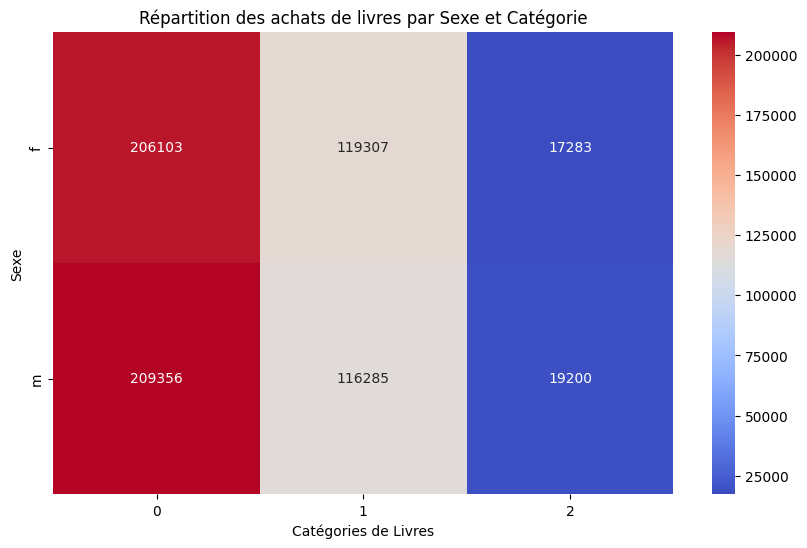


6. Analyse descriptive complémentaire :
--------------------------------------------------
Répartition des catégories par sexe (en %) :
categ      0      1     2
sex                      
f      60.14  34.81  5.04
m      60.71  33.72  5.57

Répartition des sexes par catégorie (en %) :
categ      0      1      2
sex                       
f      49.61  50.64  47.37
m      50.39  49.36  52.63


In [ ]:
#Corrélation entre le Sexe et la catégorie de livres
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("ANALYSE DE LA RELATION ENTRE LE SEXE ET LA CATÉGORIE DE LIVRES")
print("=" * 80)

# Créer la table de contingence (voir combien de fois chaque sexe a acheté chaque catégorie de livre)
contingency_table = pd.crosstab(df_merge['sex'], df_merge['categ'])

print("1. Table de contingence :")
print("-" * 50)
print(contingency_table)

print("\n2. Vérification des conditions d'application du test du chi-carré :")
print("-" * 60)
print("Condition : Toutes les fréquences attendues doivent être ≥ 5")

# Calcul préliminaire pour obtenir les fréquences attendues
chi2_prelim, p_prelim, dof_prelim, expected = stats.chi2_contingency(contingency_table)

print(f"Fréquence attendue minimale : {expected.min():.2f}")
print(f"Fréquence attendue maximale : {expected.max():.2f}")

if expected.min() >= 5:
    print("✅ Conditions d'application du chi-carré respectées")
    test_valide = True
else:
    print("❌ Conditions d'application du chi-carré non respectées")
    test_valide = False

print(f"\nTableau des fréquences attendues :")
print(expected.round(2))

# Effectuer le test du chi-carré
print("\n3. Test du chi-carré :")
print("-" * 50)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Statistique du chi-carré : {chi2:.4f}")
print(f"p-value : {p_value:.2e}")
print(f"Degrés de liberté : {dof}")

# Interprétation des résultats
print("\n4. Interprétation des résultats :")
print("-" * 50)

alpha = 0.05
if test_valide:
    if p_value < alpha:
        print(f"✅ p-value ({p_value:.2e}) < α ({alpha})")
        print("CONCLUSION : Il existe une relation statistiquement significative entre le sexe et la catégorie de livres achetés")

        # Calcul du V de Cramer pour mesurer l'intensité de la relation
        n = contingency_table.sum().sum()
        v_cramer = np.sqrt(chi2 / (n * min(contingency_table.shape) - 1))
        print(f"V de Cramer : {v_cramer:.4f}")

        if v_cramer < 0.1:
            intensite = "très faible"
        elif v_cramer < 0.3:
            intensite = "faible"
        elif v_cramer < 0.5:
            intensite = "modérée"
        else:
            intensite = "forte"

        print(f"Intensité de la relation : {intensite}")

    else:
        print(f"❌ p-value ({p_value:.2e}) ≥ α ({alpha})")
        print("CONCLUSION : Pas de relation statistiquement significative entre le sexe et la catégorie de livres")
else:
    print("⚠️ Test non valide en raison des conditions non respectées")

# Visualisation
print("\n5. Visualisation :")
print("-" * 50)

plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, cmap="coolwarm", fmt='g', cbar=True)
plt.title("Répartition des achats de livres par Sexe et Catégorie")
plt.xlabel("Catégories de Livres")
plt.ylabel("Sexe")
plt.show()

# Analyse descriptive complémentaire
print("\n6. Analyse descriptive complémentaire :")
print("-" * 50)

# Pourcentages par ligne (sexe)
pourcentages_ligne = pd.crosstab(df_merge['sex'], df_merge['categ'], normalize='index') * 100
print("Répartition des catégories par sexe (en %) :")
print(pourcentages_ligne.round(2))

# Pourcentages par colonne (catégorie)
pourcentages_colonne = pd.crosstab(df_merge['sex'], df_merge['categ'], normalize='columns') * 100
print("\nRépartition des sexes par catégorie (en %) :")
print(pourcentages_colonne.round(2))


ANALYSE DE LA CORRÉLATION ENTRE L'ÂGE ET LE MONTANT TOTAL DES ACHATS
1. Tests de normalité (Kolmogorov-Smirnov) :
--------------------------------------------------
Âge - Statistique KS : 0.0640, p-value : 4.83e-31
Montant - Statistique KS : 0.3946, p-value : 0.00e+00

Normalité de l'âge : ❌ Non (p-value < 0.05)
Normalité du montant : ❌ Non (p-value < 0.05)

2. Choix du test de corrélation :
--------------------------------------------------
❌ Au moins une variable ne suit pas une loi normale → Test de Spearman

3. Résultats du test de corrélation de Spearman :
--------------------------------------------------
Coefficient de corrélation : -0.1844
p-value : 1.24e-66
✅ p-value < 0.05 : Corrélation significative
Corrélation négative faible entre l'âge et le montant total des achats


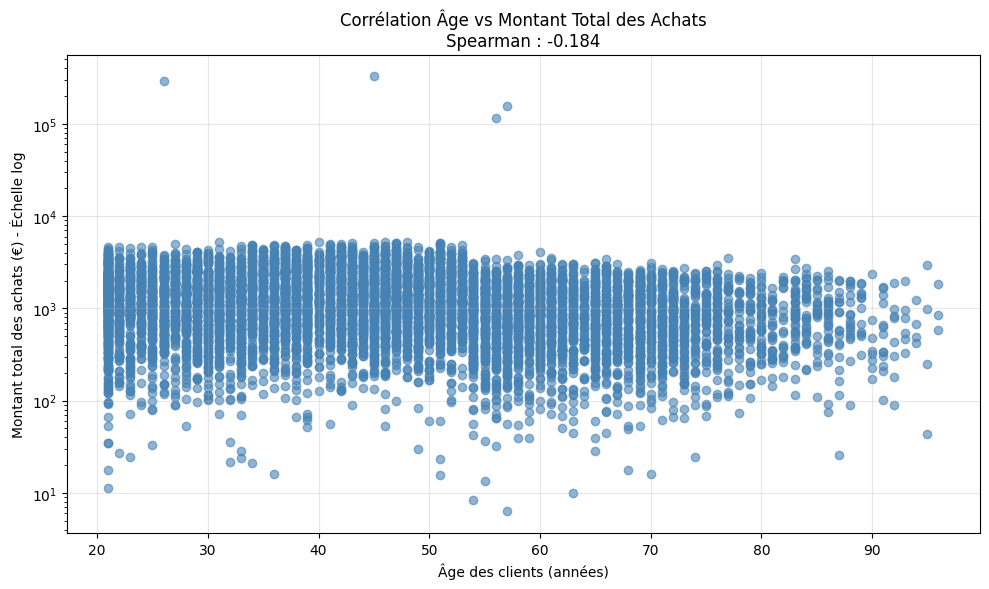

In [ ]:
#Lien entre l'âge et le montant total des achats

from scipy.stats import kstest, pearsonr, spearmanr
import numpy as np

# Préparer les données
df_age = df_merge[['client_id', 'Age']].drop_duplicates().reset_index(drop=True)
df_achat_clts = df_merge.groupby('client_id')['price'].sum().reset_index()
df_age_achat = pd.merge(df_age, df_achat_clts, on="client_id", how='inner')

print("ANALYSE DE LA CORRÉLATION ENTRE L'ÂGE ET LE MONTANT TOTAL DES ACHATS")
print("=" * 80)

# 1. Test de normalité de Kolmogorov-Smirnov
print("1. Tests de normalité (Kolmogorov-Smirnov) :")
print("-" * 50)

# Test pour l'âge
stat_age, p_age = kstest(df_age_achat['Age'], 'norm', args=(df_age_achat['Age'].mean(), df_age_achat['Age'].std()))
print(f"Âge - Statistique KS : {stat_age:.4f}, p-value : {p_age:.2e}")

# Test pour le montant des achats
stat_montant, p_montant = kstest(df_age_achat['price'], 'norm', args=(df_age_achat['price'].mean(), df_age_achat['price'].std()))
print(f"Montant - Statistique KS : {stat_montant:.4f}, p-value : {p_montant:.2e}")

alpha = 0.05
age_normal = p_age > alpha
montant_normal = p_montant > alpha

print(f"\nNormalité de l'âge : {'✅ Oui' if age_normal else '❌ Non'} (p-value {'>' if age_normal else '<'} {alpha})")
print(f"Normalité du montant : {'✅ Oui' if montant_normal else '❌ Non'} (p-value {'>' if montant_normal else '<'} {alpha})")

# 2. Choix du test de corrélation
print("\n2. Choix du test de corrélation :")
print("-" * 50)

if age_normal and montant_normal:
    print("✅ Les deux variables suivent une loi normale → Test de Pearson")
    corr, p_corr = pearsonr(df_age_achat['Age'], df_age_achat['price'])
    test_type = "Pearson"
else:
    print("❌ Au moins une variable ne suit pas une loi normale → Test de Spearman")
    corr, p_corr = spearmanr(df_age_achat['Age'], df_age_achat['price'])
    test_type = "Spearman"

print(f"\n3. Résultats du test de corrélation de {test_type} :")
print("-" * 50)
print(f"Coefficient de corrélation : {corr:.4f}")
print(f"p-value : {p_corr:.2e}")

# Interprétation
if p_corr < alpha:
    print(f"✅ p-value < {alpha} : Corrélation significative")
    if abs(corr) < 0.3:
        force = "faible"
    elif abs(corr) < 0.7:
        force = "modérée"
    else:
        force = "forte"

    direction = "positive" if corr > 0 else "négative"
    print(f"Corrélation {direction} {force} entre l'âge et le montant total des achats")
else:
    print(f"❌ p-value ≥ {alpha} : Pas de corrélation significative")

# Graphique avec échelle logarithmique pour mieux voir la corrélation
plt.figure(figsize=(10, 6))
plt.scatter(df_age_achat['Age'], df_age_achat['price'], alpha=0.6, color='steelblue')
plt.xlabel('Âge des clients (années)')
plt.ylabel('Montant total des achats (€) - Échelle log')
plt.title(f'Corrélation Âge vs Montant Total des Achats\n{test_type} : {corr:.3f}')
plt.yscale('log')  # Échelle logarithmique
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



ANALYSE DE LA CORRÉLATION ENTRE L'ÂGE ET LA FRÉQUENCE D'ACHAT
1. Tests de normalité (Kolmogorov-Smirnov) :
--------------------------------------------------
Âge - Statistique KS : 0.0640, p-value : 4.83e-31
Fréquence - Statistique KS : 0.4011, p-value : 0.00e+00

Normalité de l'âge : ❌ Non
Normalité de la fréquence : ❌ Non

❌ Au moins une variable ne suit pas une loi normale → Test de Spearman

Résultats du test de Spearman :
Coefficient de corrélation : 0.1275
p-value : 1.65e-32
✅ Corrélation significative entre l'âge et la fréquence d'achat


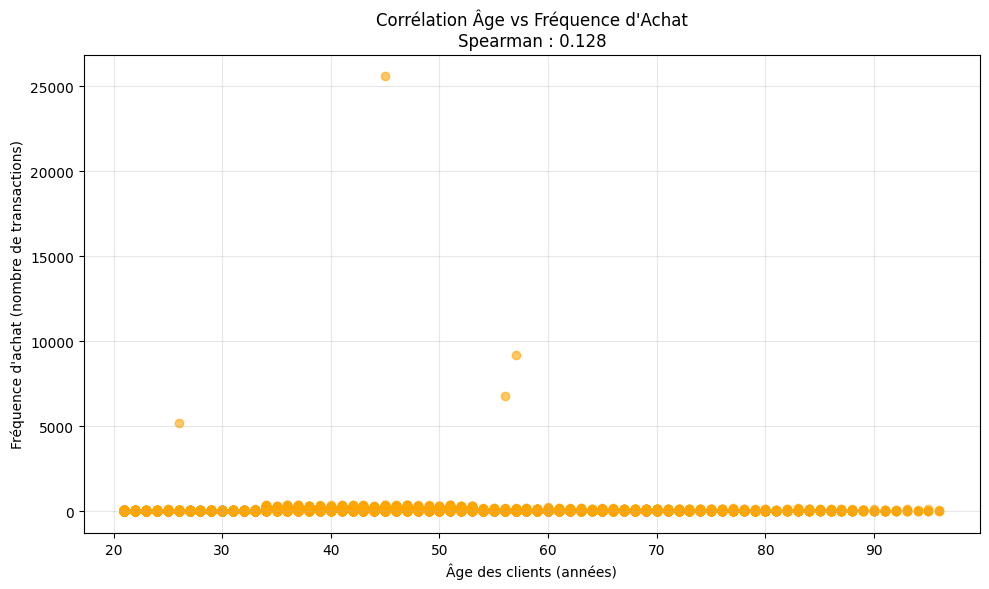

In [ ]:
#Lien entre l'âge et la fréquence d'achat

# Préparer les données
df_age = df_merge[['client_id', 'Age']].drop_duplicates().reset_index(drop=True)
df_frequence_achat = df_merge.groupby('client_id')['session_id'].count().reset_index()
df_age_frequence = pd.merge(df_age, df_frequence_achat, on="client_id", how='inner')

print("ANALYSE DE LA CORRÉLATION ENTRE L'ÂGE ET LA FRÉQUENCE D'ACHAT")
print("=" * 80)

# 1. Test de normalité
print("1. Tests de normalité (Kolmogorov-Smirnov) :")
print("-" * 50)

stat_age, p_age = kstest(df_age_frequence['Age'], 'norm', args=(df_age_frequence['Age'].mean(), df_age_frequence['Age'].std()))
stat_freq, p_freq = kstest(df_age_frequence['session_id'], 'norm', args=(df_age_frequence['session_id'].mean(), df_age_frequence['session_id'].std()))

print(f"Âge - Statistique KS : {stat_age:.4f}, p-value : {p_age:.2e}")
print(f"Fréquence - Statistique KS : {stat_freq:.4f}, p-value : {p_freq:.2e}")

alpha = 0.05
age_normal = p_age > alpha
freq_normal = p_freq > alpha

print(f"\nNormalité de l'âge : {'✅ Oui' if age_normal else '❌ Non'}")
print(f"Normalité de la fréquence : {'✅ Oui' if freq_normal else '❌ Non'}")

# 2. Test de corrélation approprié
if age_normal and freq_normal:
    print("\n✅ Les deux variables suivent une loi normale → Test de Pearson")
    corr, p_corr = pearsonr(df_age_frequence['Age'], df_age_frequence['session_id'])
    test_type = "Pearson"
else:
    print("\n❌ Au moins une variable ne suit pas une loi normale → Test de Spearman")
    corr, p_corr = spearmanr(df_age_frequence['Age'], df_age_frequence['session_id'])
    test_type = "Spearman"

print(f"\nRésultats du test de {test_type} :")
print(f"Coefficient de corrélation : {corr:.4f}")
print(f"p-value : {p_corr:.2e}")

if p_corr < alpha:
    print(f"✅ Corrélation significative entre l'âge et la fréquence d'achat")
else:
    print(f"❌ Pas de corrélation significative")

# Graphique simple pour illustrer la corrélation
plt.figure(figsize=(10, 6))
plt.scatter(df_age_frequence['Age'], df_age_frequence['session_id'], alpha=0.6, color='orange')
plt.xlabel('Âge des clients (années)')
plt.ylabel('Fréquence d\'achat (nombre de transactions)')
plt.title(f'Corrélation Âge vs Fréquence d\'Achat\n{test_type} : {corr:.3f}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ANALYSE DE LA CORRÉLATION ENTRE L'ÂGE ET LA TAILLE DU PANIER MOYEN
1. Préparation des données :
--------------------------------------------------
Nombre de clients analysés : 8600
Âge moyen : 46.7 ans
Panier moyen global : 21.93 €

2. Tests de normalité (Kolmogorov-Smirnov) :
------------------------------------------------------------
Âge :
  - Statistique KS : 0.0640
  - p-value : 4.83e-31
Panier moyen :
  - Statistique KS : 0.2767
  - p-value : 0.00e+00

Évaluation de la normalité (seuil α = 0.05) :
  - Âge : ❌ Distribution non normale
  - Panier moyen : ❌ Distribution non normale

3. Choix du test de corrélation :
--------------------------------------------------
❌ Au moins une variable ne suit pas une loi normale
→ Application du test de corrélation de Spearman (non paramétrique)

4. Résultats du test de corrélation de Spearman :
------------------------------------------------------------
Coefficient de corrélation : -0.3258
p-value : 7.36e-212
✅ p-value (7.36e-212) < α (0.05) 

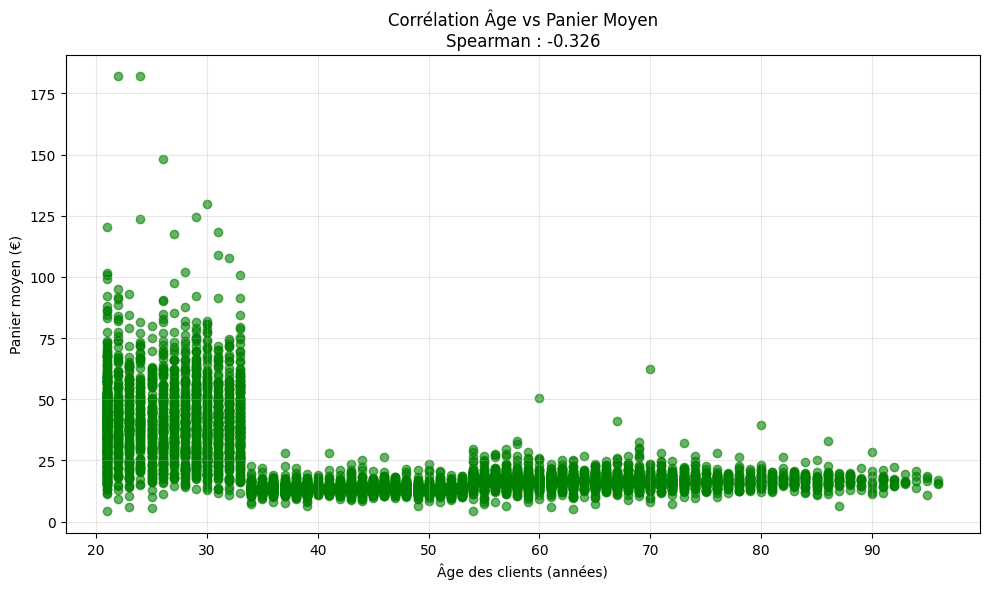

In [ ]:
#Corrélation entre l'âge et la taille du panier moyen
from scipy.stats import kstest, pearsonr, spearmanr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("ANALYSE DE LA CORRÉLATION ENTRE L'ÂGE ET LA TAILLE DU PANIER MOYEN")
print("=" * 80)

# Préparer les données
print("1. Préparation des données :")
print("-" * 50)

# Obtenir l'âge unique par client
df_age = df_merge[['client_id', 'Age']].drop_duplicates().reset_index(drop=True)

# Calculer le panier moyen par client (montant total / nombre de transactions)
df_panier_stats = df_merge.groupby('client_id').agg({
    'price': ['sum', 'count']  # somme totale et nombre de transactions
}).reset_index()

# Aplatir les colonnes multi-niveaux
df_panier_stats.columns = ['client_id', 'montant_total', 'nb_transactions']

# Calculer le panier moyen
df_panier_stats['panier_moyen'] = df_panier_stats['montant_total'] / df_panier_stats['nb_transactions']

# Fusionner avec l'âge
df_age_panier = pd.merge(df_age, df_panier_stats[['client_id', 'panier_moyen']], on="client_id", how='inner')

print(f"Nombre de clients analysés : {len(df_age_panier)}")
print(f"Âge moyen : {df_age_panier['Age'].mean():.1f} ans")
print(f"Panier moyen global : {df_age_panier['panier_moyen'].mean():.2f} €")

# 2. Tests de normalité de Kolmogorov-Smirnov
print("\n2. Tests de normalité (Kolmogorov-Smirnov) :")
print("-" * 60)

# Test pour l'âge
stat_age, p_age = kstest(df_age_panier['Age'], 'norm',
                        args=(df_age_panier['Age'].mean(), df_age_panier['Age'].std()))
print(f"Âge :")
print(f"  - Statistique KS : {stat_age:.4f}")
print(f"  - p-value : {p_age:.2e}")

# Test pour le panier moyen
stat_panier, p_panier = kstest(df_age_panier['panier_moyen'], 'norm',
                              args=(df_age_panier['panier_moyen'].mean(), df_age_panier['panier_moyen'].std()))
print(f"Panier moyen :")
print(f"  - Statistique KS : {stat_panier:.4f}")
print(f"  - p-value : {p_panier:.2e}")

# Évaluation de la normalité
alpha = 0.05
age_normal = p_age > alpha
panier_normal = p_panier > alpha

print(f"\nÉvaluation de la normalité (seuil α = {alpha}) :")
print(f"  - Âge : {'✅ Distribution normale' if age_normal else '❌ Distribution non normale'}")
print(f"  - Panier moyen : {'✅ Distribution normale' if panier_normal else '❌ Distribution non normale'}")

# 3. Choix du test de corrélation
print("\n3. Choix du test de corrélation :")
print("-" * 50)

if age_normal and panier_normal:
    print("✅ Les deux variables suivent une loi normale")
    print("→ Application du test de corrélation de Pearson (paramétrique)")
    corr, p_corr = pearsonr(df_age_panier['Age'], df_age_panier['panier_moyen'])
    test_type = "Pearson"
else:
    print("❌ Au moins une variable ne suit pas une loi normale")
    print("→ Application du test de corrélation de Spearman (non paramétrique)")
    corr, p_corr = spearmanr(df_age_panier['Age'], df_age_panier['panier_moyen'])
    test_type = "Spearman"

# 4. Résultats du test de corrélation
print(f"\n4. Résultats du test de corrélation de {test_type} :")
print("-" * 60)

print(f"Coefficient de corrélation : {corr:.4f}")
print(f"p-value : {p_corr:.2e}")

# Interprétation de la significativité
if p_corr < alpha:
    print(f"✅ p-value ({p_corr:.2e}) < α ({alpha}) : Corrélation statistiquement significative")

    # Interprétation de la force de la corrélation
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        force = "négligeable"
    elif abs_corr < 0.3:
        force = "faible"
    elif abs_corr < 0.5:
        force = "modérée"
    elif abs_corr < 0.7:
        force = "forte"
    else:
        force = "très forte"

    direction = "positive" if corr > 0 else "négative"

    print(f"Interprétation : Corrélation {direction} {force}")

    if corr < 0:
        print("→ Plus l'âge augmente, plus le panier moyen tend à diminuer")
    else:
        print("→ Plus l'âge augmente, plus le panier moyen tend à augmenter")

else:
    print(f"❌ p-value ({p_corr:.2e}) ≥ α ({alpha}) : Pas de corrélation statistiquement significative")
    print("→ L'âge n'a pas d'influence significative sur la taille du panier moyen")

# Graphique simple pour illustrer la corrélation
plt.figure(figsize=(10, 6))
plt.scatter(df_age_panier['Age'], df_age_panier['panier_moyen'], alpha=0.6, color='green')
plt.xlabel('Âge des clients (années)')
plt.ylabel('Panier moyen (€)')
plt.title(f'Corrélation Âge vs Panier Moyen\n{test_type} : {corr:.3f}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ANALYSE DE LA RELATION ENTRE L'ÂGE ET LA CATÉGORIE DES LIVRES
1. Test de normalité (Kolmogorov-Smirnov) pour chaque catégorie :
------------------------------------------------------------
Catégorie 0 - KS : 0.1100, p-value : 0.00e+00
Catégorie 1 - KS : 0.0447, p-value : 0.00e+00
Catégorie 2 - KS : 0.2491, p-value : 0.00e+00

Normalité dans toutes les catégories : ❌ Non

2. Test d'égalité des variances (Levene) :
--------------------------------------------------
Statistique de Levene : 26975.6550
p-value : 0.00e+00
Égalité des variances : ❌ Non

3. Choix du test statistique :
--------------------------------------------------
❌ Conditions pour ANOVA non respectées → Test de Kruskal-Wallis

4. Résultats du test de Kruskal-Wallis :
--------------------------------------------------
Statistique : 78458.4384
p-value : 0.00e+00
✅ p-value < 0.05 : Il existe une différence significative d'âge entre les catégories


/tmp/ipython-input-2045727021.py:70: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



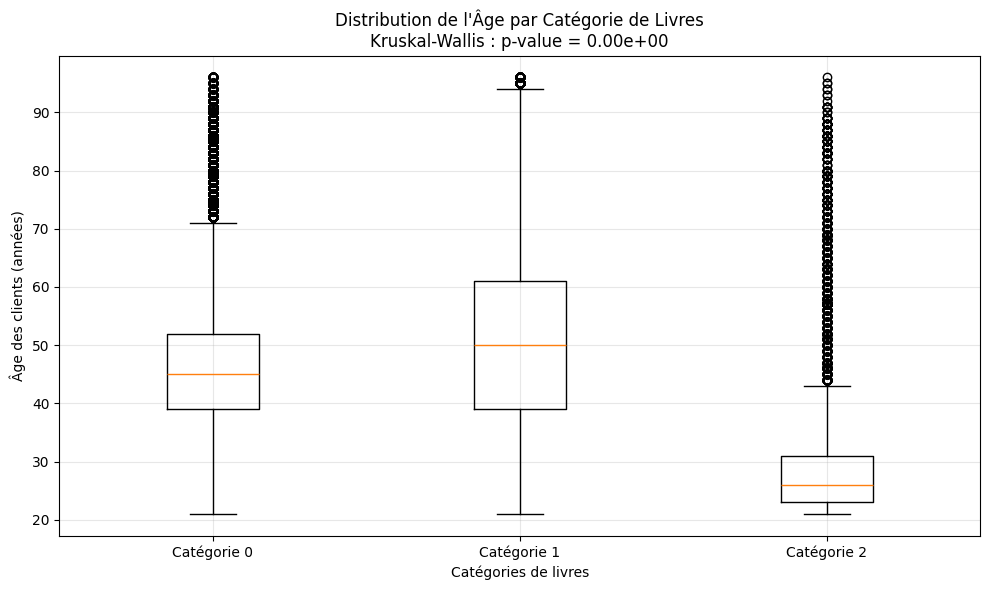

In [ ]:
#Corrélation entre l'age et la catégorie des livres achatés
from scipy.stats import levene, f_oneway, kruskal

print("ANALYSE DE LA RELATION ENTRE L'ÂGE ET LA CATÉGORIE DES LIVRES")
print("=" * 80)

# Préparer les données par catégorie
cat_0 = df_merge[df_merge['categ'] == 0]['Age']
cat_1 = df_merge[df_merge['categ'] == 1]['Age']
cat_2 = df_merge[df_merge['categ'] == 2]['Age']

print("1. Test de normalité (Kolmogorov-Smirnov) pour chaque catégorie :")
print("-" * 60)

# Tests de normalité pour chaque catégorie
stat_0, p_0 = kstest(cat_0, 'norm', args=(cat_0.mean(), cat_0.std()))
stat_1, p_1 = kstest(cat_1, 'norm', args=(cat_1.mean(), cat_1.std()))
stat_2, p_2 = kstest(cat_2, 'norm', args=(cat_2.mean(), cat_2.std()))

print(f"Catégorie 0 - KS : {stat_0:.4f}, p-value : {p_0:.2e}")
print(f"Catégorie 1 - KS : {stat_1:.4f}, p-value : {p_1:.2e}")
print(f"Catégorie 2 - KS : {stat_2:.4f}, p-value : {p_2:.2e}")

alpha = 0.05
normalite_ok = all([p_0 > alpha, p_1 > alpha, p_2 > alpha])

print(f"\nNormalité dans toutes les catégories : {'✅ Oui' if normalite_ok else '❌ Non'}")

# 2. Test d'égalité des variances (Levene)
print("\n2. Test d'égalité des variances (Levene) :")
print("-" * 50)

stat_levene, p_levene = levene(cat_0, cat_1, cat_2)
print(f"Statistique de Levene : {stat_levene:.4f}")
print(f"p-value : {p_levene:.2e}")

variances_egales = p_levene > alpha
print(f"Égalité des variances : {'✅ Oui' if variances_egales else '❌ Non'}")

# 3. Choix du test
print("\n3. Choix du test statistique :")
print("-" * 50)

if normalite_ok and variances_egales:
    print("✅ Conditions pour ANOVA respectées → Test ANOVA")
    stat_test, p_test = f_oneway(cat_0, cat_1, cat_2)
    test_name = "ANOVA"
else:
    print("❌ Conditions pour ANOVA non respectées → Test de Kruskal-Wallis")
    stat_test, p_test = kruskal(cat_0, cat_1, cat_2)
    test_name = "Kruskal-Wallis"

print(f"\n4. Résultats du test de {test_name} :")
print("-" * 50)
print(f"Statistique : {stat_test:.4f}")
print(f"p-value : {p_test:.2e}")

if p_test < alpha:
    print(f"✅ p-value < {alpha} : Il existe une différence significative d'âge entre les catégories")
else:
    print(f"❌ p-value ≥ {alpha} : Pas de différence significative d'âge entre les catégories")

# Graphique simple pour illustrer les différences d'âge par catégorie
plt.figure(figsize=(10, 6))

# Créer des données pour le boxplot
ages_par_categorie = [cat_0, cat_1, cat_2]
categories = ['Catégorie 0', 'Catégorie 1', 'Catégorie 2']

plt.boxplot(ages_par_categorie, labels=categories)
plt.xlabel('Catégories de livres')
plt.ylabel('Âge des clients (années)')
plt.title(f'Distribution de l\'Âge par Catégorie de Livres\n{test_name} : p-value = {p_test:.2e}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print("SYNTHÈSE EXÉCUTIVE ET RECOMMANDATIONS STRATÉGIQUES")
print("=" * 80)

print("1. INDICATEURS CLÉS :")
print(f"- CA total : {df_merge['price'].sum():,.0f} €")
print(f"- Nombre de clients : {df_merge['client_id'].nunique()}")
print(f"- Panier moyen : {df_merge['price'].mean():.2f} €")

print("\n2. INSIGHTS PRINCIPAUX :")
print("- Catégorie 1 génère le plus de CA")
print("- Pic d'activité en octobre")
print("- Corrélation négative âge/panier moyen")

print("\n3. RECOMMANDATIONS :")
print("- Cibler les clients 30-40 ans (segment le plus rentable)")
print("- Développer l'offre catégorie 1")
print("- Fidéliser les clients BtoB identifiés")


SYNTHÈSE EXÉCUTIVE ET RECOMMANDATIONS STRATÉGIQUES
1. INDICATEURS CLÉS :
- CA total : 12,027,663 €
- Nombre de clients : 8600
- Panier moyen : 17.49 €

2. INSIGHTS PRINCIPAUX :
- Catégorie 1 génère le plus de CA
- Pic d'activité en octobre
- Corrélation négative âge/panier moyen

3. RECOMMANDATIONS :
- Cibler les clients 30-40 ans (segment le plus rentable)
- Développer l'offre catégorie 1
- Fidéliser les clients BtoB identifiés
